In [1]:
import sys, os, torch, pdb
import numpy as np
import torch.nn as nn

sys.path.append('../')
sys.path.append('../../')
cwd = os.getcwd()

from Modules.helpers.performance.density.plotting_loss_running_min import plot_running_min_val_loss_broken_x_log_lst
from Modules.helpers.performance.density.plotting_final_loss import plot_final_loss_lst
from Modules.helpers.performance.plotting_timings import plot_total_run_times_lst
from Modules.helpers.performance.diffusion.plotting_mse_running_min import plot_running_min_MSE_diff_loss_broken_x_log_lst
from Modules.helpers.performance.diffusion.plotting_final_mse import plot_diff_mse_lst

from Modules.helpers.plotting_profiles import (plot_initial_condition_1d, 
                                               plot_eval2)
from file_finder import (paths_to_df,
                         find_data_obj_files, 
                         condense_df,
                         print_path_components)
from Modules.helpers.parse import dictToPath

# Add to main
from data.python.Modules.dataClass import OriginalData, Data
from binn.python.Modules.Models.BuildBINNs_1D import BINN,u_MLP, D_MLP
from binn.python.Modules.Utils.ModelWrapper_1D import ModelWrapper
from binn.python.Modules.Models.BuildBINNs_1D import BINN,u_MLP


ext  = "dataObj/original?_1/DValue_0.024720000000000002/rValue_1.536/gamma_0.2/K_1700.0/xNum_38/tNum_5/originalDataObj.npy"
data_orig_obj_FKPP = np.load(os.path.join('../../', ext),allow_pickle=True).item(0)

In [2]:
def generate_random_inputs(self,inputs):
    torch.manual_seed(self.loss_count)  
    torch.cuda.manual_seed(self.loss_count)
    samples = torch.rand(self.num_samples*2, 1, requires_grad=True)
    t = samples[:self.num_samples]
    x = samples[self.num_samples:]
    x = x * (self.x_max - self.x_min) + self.x_min
    t = t * (self.t_max - self.t_min) + self.t_min
    return torch.cat([x, t], dim=1).float().to(inputs.device)

def generate_bc_inputs(self, inputs):
    torch.manual_seed(self.loss_count)
    torch.cuda.manual_seed(self.loss_count)
    t = torch.rand(self.num_bcs, 1, requires_grad=True,
                   device=inputs.device) * (self.t_max - self.t_min) + self.t_min
    torch.manual_seed(self.loss_count)
    torch.cuda.manual_seed(self.loss_count)
    selector = torch.randint(0, 2, (self.num_bcs, 1), device=inputs.device, dtype=torch.bool)
    x_left  = torch.full_like(t, self.x_min)
    x_right = torch.full_like(t, self.x_max)
    x = torch.where(selector, x_left, x_right)
    return torch.cat([x, t], dim=1)

def bc_no_flux_loss(self, inputs_bc, u_bc):
    dudx = Gradient(u_bc, inputs_bc, order=1)[:, 0][:, None]   # x–component
    return self.bc_weight * dudx.pow(2)

def apply_constraints(self, D, G, t, u):
    self.D_loss = 0
    self.G_loss = 0
    self.D_loss += self.D_weight*torch.where(
            D <  self.alpha_D_min, (D -self.alpha_D_min)**2, torch.zeros_like(D))
    self.D_loss += self.D_weight*torch.where(
            D >  self.alpha_D_max, (D - self.alpha_D_max)**2, torch.zeros_like(D))
    try:
        dDdu = Gradient(D, u, order=1)
        self.D_loss += self.dDdu_weight*torch.where(
                dDdu < 0.0, dDdu**2, torch.zeros_like(dDdu))
    except:
        pass
    if G is not None:
        self.G_loss += self.G_weight*torch.where(
                G < self.G_min, (G-self.G_min)**2, torch.zeros_like(G)) 
        self.G_loss += self.G_weight*torch.where(
                G > self.G_max, (G-self.G_max)**2, torch.zeros_like(G))
        try:
            dGdu = Gradient(G, u, order=1)
            self.G_loss += self.dGdu_weight*torch.where(
                dGdu > 0.0, dGdu**2, torch.zeros_like(dGdu))
        except:
            pass
    
def pde_loss(self, inputs, outputs):
    x = inputs[:, 0][:,None]
    t = inputs[:, 1][:,None]
    u = outputs.clone()
    d1 = Gradient(u, inputs, order=1)
    ux = d1[:, 0][:, None]
    ut = d1[:, 1][:, None]
    D = self.diffusion(u) if self.diffusion.inputs == 1 else self.diffusion(u, t)
    LHS = ut
    if self.growth:
        G = self.growth(u) if self.growth.inputs == 1 else self.growth(u, t)
        RHS = self.D_max * Gradient(D * ux, inputs)[:, 0][:, None] + self.G_max * G * u
    else:
        RHS = self.D_max * Gradient(D * ux, inputs)[:, 0][:, None]
        G = None
    pde_loss = (LHS - RHS) ** 2
    apply_constraints(self, D, G, t, u)
    return pde_loss + self.D_loss + self.G_loss 

## Choose and load data

In [3]:
x = data_orig_obj_FKPP.x
t = data_orig_obj_FKPP.t
K = 1
inital_path = os.path.join('../../', "DataObj")

# ==================== Display available data objects ====================
data_df = paths_to_df(find_data_obj_files(start_dir = inital_path,
                                           target_filename="data_obj.npy"))
#data_df

In [4]:
xNum = len(x)
tNum = len(t)
gamma = 0
noise_percent = 0
IC_label = "cos"
diff_label= "const"
grow_label = "zero"
seed = 0

# =================== Choose data object ====================
data_info = {
        "dataXnum":xNum,
        "dataTnum":tNum ,
        "dataK": K,
        "dataICLabel": IC_label,
        "dataDiffLabel": diff_label,
        "dataGrowLabel": grow_label,
        "dataGamma": gamma,
        "dataNoisePercent": noise_percent,
        "dataNoiseSeed": seed
    }
data_df_updated = condense_df(data_df, data_info)
data_file_path = data_df_updated["full_path"][0]
data_df_updated

,full_path,dataXnum,dataTnum,dataK,dataICLabel,dataDiffLabel,dataGrowLabel,dataGamma,dataNoisePercent,dataNoiseSeed,data
0,../../DataObj/dataXnum_38/dataTnum_5/dataK_1/d...,38,5,1,cos,const,zero,0,0,0,obj.npy


MSE between u and u_clean: 0.0
ABS between u and u_clean [cells]: 0.0
ABS (%) between u and u_clean: 0.0


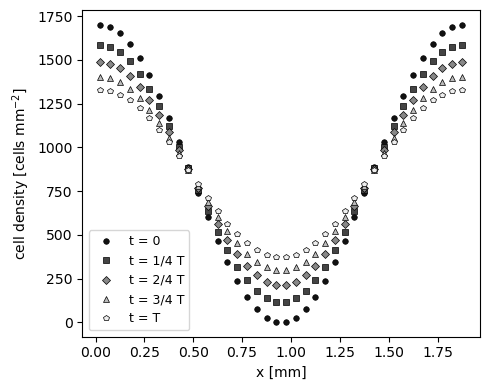

In [5]:
# ==================== Load data object ====================
data_obj = np.load(data_file_path,allow_pickle=True).item()
plot_initial_condition_1d(data_obj)

## Choose and load binn model

In [6]:
binn_df = paths_to_df(find_data_obj_files(start_dir='../../', target_filename="binnModel0.pth"))
binn_batch_size = 38
binn_rel_update_thresh = 0.05
binn_lr = 1e-3
binn_split_seed = 0
binn_two_step_bool = 0

fixed_filters = {
        "dataXnum":xNum,
        "dataTnum":tNum,
        "dataK": K,
        "dataICLabel": IC_label,
        "dataDiffLabel": diff_label,
        "dataGrowLabel": grow_label,
        "dataGamma": gamma,
        "dataNoisePercent": noise_percent,
        "dataNoiseSeed": seed,
        "binnLR": binn_lr,
        "binnBatchSize": binn_batch_size,
        "binnRelSaveThresh": binn_rel_update_thresh,
        "twoStepBool":         binn_two_step_bool
        }
binn_df1 = condense_df(binn_df, fixed_filters)
binn_df1

,full_path,dataXnum,dataTnum,dataK,dataICLabel,dataDiffLabel,dataGrowLabel,dataGamma,dataNoisePercent,dataNoiseSeed,...,twoStepBool,binnLR,binnBatchSize,binnRelUpdateThresh,binnRelSaveThresh,binnES,combineDenoise,binnModelLabel,binnTVmethod,binnDOneParamBool
0,../../binn/dataXnum_38/dataTnum_5/dataK_1/data...,38,5,1,cos,const,zero,0,0,0,...,0,0.001,38,NaN,0.05,2000,NaN,NaN,random,False
1,../../binn/dataXnum_38/dataTnum_5/dataK_1/data...,38,5,1,cos,const,zero,0,0,0,...,0,0.001,38,NaN,0.05,3000,NaN,NaN,random,False
2,../../binn/dataXnum_38/dataTnum_5/dataK_1/data...,38,5,1,cos,const,zero,0,0,0,...,0,0.001,38,NaN,0.05,5000,NaN,NaN,random,False
3,../../binn/dataXnum_38/dataTnum_5/dataK_1/data...,38,5,1,cos,const,zero,0,0,0,...,0,0.001,38,NaN,0.05,1000,NaN,NaN,random,False
4,../../binn/dataXnum_38/dataTnum_5/dataK_1/data...,38,5,1,cos,const,zero,0,0,0,...,0,0.001,38,NaN,0.05,2000,NaN,NaN,random,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
206,../../binn/dataXnum_38/dataTnum_5/dataK_1/data...,38,5,1,cos,const,zero,0,0,0,...,0,0.001,38,NaN,0.05,2000,NaN,NaN,random,False
207,../../binn/dataXnum_38/dataTnum_5/dataK_1/data...,38,5,1,cos,const,zero,0,0,0,...,0,0.001,38,NaN,0.05,3000,NaN,NaN,random,False
208,../../binn/dataXnum_38/dataTnum_5/dataK_1/data...,38,5,1,cos,const,zero,0,0,0,...,0,0.001,38,NaN,0.05,5000,NaN,NaN,random,False
209,../../binn/dataXnum_38/dataTnum_5/dataK_1/data...,38,5,1,cos,const,zero,0,0,0,...,0,0.001,38,NaN,0.05,1000,NaN,NaN,random,False


In [7]:
binnVF = 0.2
binn_model_num = 0
D_one_param_bool = False
G_size = None
binnInitializeDenoiseBool = 0
two_step_bool = 0

# =============== USER input ==================
binn_ES_list = [1000,2000,3000]  # list of ES values
binnSplitSeeds = [0, 1, 2]
u_NN_lst = [8, 16, 32, 64, 128]
D_NN_lst = [1, 2, 4]
binn_models_by_ES = {}
# ==============================================

for binn_ES in binn_ES_list:
    binn_ext = {
        "binnVF": binnVF,
        "binnTVmethod": "random",
        "binnTVsplitSeed": binnSplitSeeds[0],  
        "binnUsize": u_NN_lst[0],              
        "binnDsize": D_NN_lst[0],            
        "binnDOneParamBool": D_one_param_bool,
        "binnGsize": G_size,
        "binnInitializeDenoiseBool": binnInitializeDenoiseBool,
        "twoStepBool": two_step_bool,
        "binnLR": binn_lr,
        "binnBatchSize": binn_batch_size,
        "binnRelSaveThresh": binn_rel_update_thresh,
        "binnES": binn_ES
    }
    binn_info = data_info.copy()
    binn_models_dics = {}
    for D_NN in D_NN_lst:
        binn_models_dics[D_NN] = {}
        for u_NN in u_NN_lst:
            binn_models_dics[D_NN][u_NN] = {}
            for binnSplitSeed in binnSplitSeeds:
                # Update model parameters
                binn_ext["binnUsize"] = u_NN
                binn_ext["binnDsize"] = D_NN
                binn_ext["binnTVsplitSeed"] = binnSplitSeed
                binn_info.update(binn_ext)
                path_to_models = os.path.join("../../binn", dictToPath(binn_info))
                file_path = os.path.join(path_to_models, f'binnModel{binn_model_num}.pth')
                binn_loaded = torch.load(file_path, weights_only=False)
                binn_loaded.load_best_val()
                binn_models_dics[D_NN][u_NN][binnSplitSeed] = binn_loaded

    # Store all models for this ES
    binn_models_by_ES[binn_ES] = binn_models_dics

diff_test = binn_models_dics[1][8][0].model.diffusion
total_p = sum(p.numel() for p in diff_test.parameters())
print(f"Number of parameters for dn NN  = {total_p}\n")

Number of parameters for dn NN  = 8



/Users/willa954/Desktop/Git-personal/arXiv_BINN_1D/Training/JN/case11/../Modules/helpers/performance/density/plotting_loss_running_min.py:222: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax1.set_xlim(left=x_min, right=break_x)
/Users/willa954/Desktop/Git-personal/arXiv_BINN_1D/Training/JN/case11/../Modules/helpers/performance/density/plotting_loss_running_min.py:385: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


saved plot: ../pngs/1D/Case11/plot_varyES/binn/NNu4_to_128.png


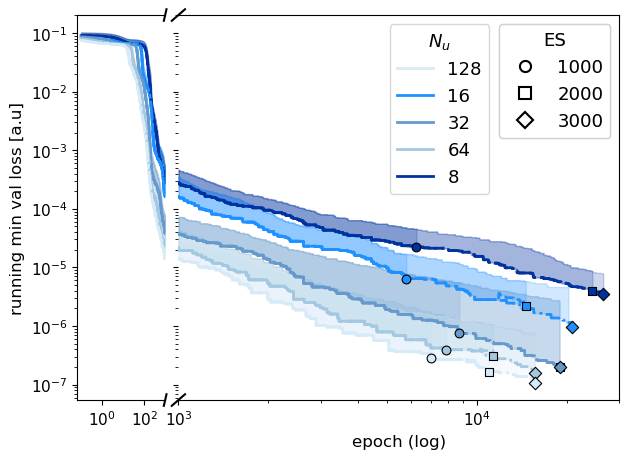

All x-axis labels found: {'32', '64', '16', '128', '8'}
saved plot: ../pngs/1D/Case11/plot_varyES/binn/NNu4_to_128_loss_bars.png


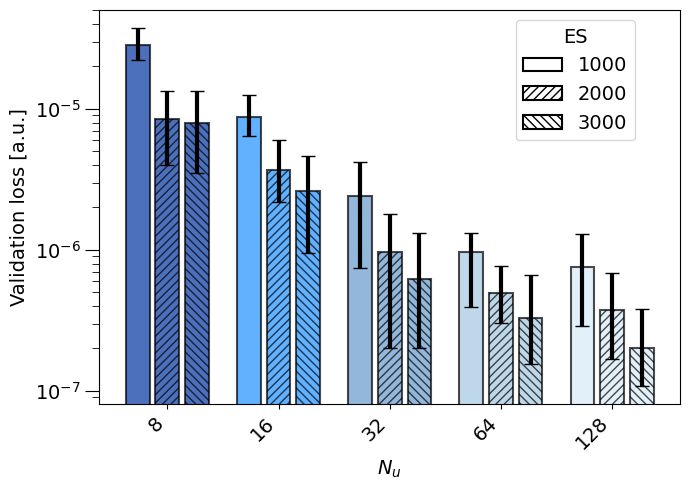

In [8]:
binn_plot = 1
binn_plot_density = True
binn_plot_times = 1

blue_colors = [
    "#0033A0", 
    "#1E90FF", 
    "#6699CC", 
    "#A4C8E1", 
    "#D6EAF8"             
]#[::-1]


linestyles = ['-']*5
marker_styles = ['o']*5

def form_labels_binn(models_dics):
    return [f"{key}" for key in models_dics.keys()]

D_NN_chosen = D_NN_lst[0]
ES_choosen = binn_ES_list[0]
binn_models_dics = binn_models_by_ES[ES_choosen]
binn_models_dics_chosen_D = binn_models_dics[D_NN_chosen]
labels = form_labels_binn(binn_models_dics_chosen_D)


binn_models_by_ES_chosen_D = []
for binn_models_dics_item in list(binn_models_by_ES.values()):
    binn_models_by_ES_chosen_D.append(binn_models_dics_item[D_NN_chosen])


model_keys = list(binn_models_dics_chosen_D.keys())
plot_params = {
    key: [blue_colors[i], linestyles[i], marker_styles[i], labels[i]]
    for i, key in enumerate(model_keys)
}

#name_intro = f'pngs/gamma_{gamma}/ESvary/NN_D{D_NN_chosen}/Initialize{binnInitializeDenoiseBool}'
name_intro = f"../pngs/1D/Case11/plot_varyES/binn"
os.makedirs(name_intro, exist_ok=True)
name_full = os.path.join(name_intro, 'NNu4_to_128.png')

plot_settings = {
    'name': name_full,
    'fill': True,
    'line_width':2,
    'legend': {
        'panel': 2,
        'loc': (0.725,1),
        "loc_upd": (1, 1),
        'fontsize': 13,
        'ncols': 1
    },
    'xaxis': {
        'min': 0,
        'max': 3e4,
        'break': 1e3
    },
    'line_lengths': {
        'hlength': 7.5e3,
        'vlength_factor': 2
    },
    'line_widths_on_axis': {
        'hwidth': 2,
        'vwidth': 2
    },
    'fontsizes': {'xaxis':12, 'xtick_labels':11, 'yaxis':12, 'ytick_labels':11},
    "figsize": (7, 5),
}

if binn_plot:  


    plot_running_min_val_loss_broken_x_log_lst(models_dics_list =binn_models_by_ES_chosen_D,
                                             plot_params=plot_params,
                                             plot_settings=plot_settings)
    bbox_to_anchor=(0.7,1)
    name_full = os.path.join(name_intro, 'NNu4_to_128_loss_bars.png')
    plot_final_loss_lst(binn_models_by_ES_chosen_D,
                                plot_params=plot_params,
                                label_list=[f"{ES}" for ES in binn_ES_list],
                                 name=name_full,
                                 bbox_to_anchor=bbox_to_anchor,
                                 y_label="Validation loss [a.u.]",
                                 legend_size=14,
                                 figsize=(7, 5))



saved plot: ../pngs/1D/Case11/plot_varyES/binn/NNu4_to_128_times.png


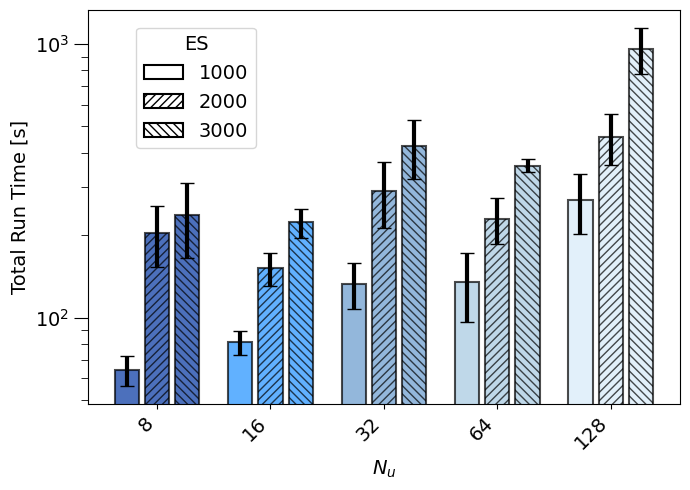

In [9]:
if binn_plot_times:
    name_full = os.path.join(name_intro, 'NNu4_to_128_times.png')
    plot_total_run_times_lst(models_dics_list=binn_models_by_ES_chosen_D,
                                plot_params=plot_params,
                                label_list=[f"{ES}" for ES in binn_ES_list],
                                legend_pos=(0.3, 0.98),
                                legend_fontsize=14,
                                 name=name_full)



/Users/willa954/Desktop/Git-personal/arXiv_BINN_1D/Training/JN/case11/../Modules/helpers/performance/diffusion/plotting_mse_running_min.py:242: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax1.set_xlim(left=x_min, right=break_x)
/Users/willa954/Desktop/Git-personal/arXiv_BINN_1D/Training/JN/case11/../Modules/helpers/performance/diffusion/plotting_mse_running_min.py:397: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


saved plot: ../pngs/1D/Case11/plot_varyES/diff/NNu4_to_128_D_mse.png


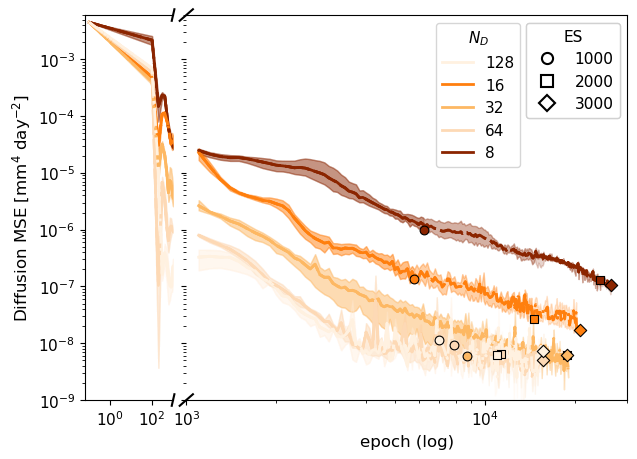

{'name': '../pngs/1D/Case11/plot_varyES/diff/NNu4_to_128_D_mse.png',
 'legend': {'panel': 2,
  'loc': (0.775, 1),
  'loc_upd': (1, 1),
  'fontsize': 11,
  'ncols': 1,
  'title': '$N_D$'},
 'fill': True,
 'xaxis': {'min': 0, 'max': 30000.0, 'break': 1000.0},
 'num_runs': 15}

In [10]:
D_colors = [
    "#8B2500",  # Burnt Orange – deep and bold
    "#FF7F0E",  # Vivid Orange – saturated, readable, classic plot color
    "#FDB863",  # Soft Tangerine – warm midtone
    "#FDD9B5",  # Peach – light orange-beige, easy on the eyes
    "#FFF1E0",  # Cream – very light accent, background-compatible
]#[:len(widths)]



u_colors = [
    "#0033A0", 
    "#1E90FF", 
    "#6699CC", 
    "#A4C8E1", 
    "#D6EAF8"             
][::-1]#[:len(widths)]
                               # hatch by depth

name_intro = f"../pngs/1D/Case11/plot_varyES/diff"
name_full = os.path.join(name_intro, 'NNu4_to_128_D_mse.png')
os.makedirs(name_intro, exist_ok=True)
plot_params = {
    key: [D_colors[i], linestyles[i], marker_styles[i], labels[i]]
    for i, key in enumerate(model_keys)
}

plot_settings = {
    'name': name_full,
    'fill': True,
    'line_width':2,
    'legend': {
        'panel': 2,
        'loc': (0.775,1),
        'loc_upd': (1, 1),
        'fontsize': 11,
        'ncols': 1
    },
    'xaxis': {
        'min': 0,
        'max': 3e4,
        'break': 1e3
    },
    'line_lengths': {
        'hlength': 7.5e3,
        'vlength_factor': 2
    },
    'line_widths_on_axis': {
        'hwidth': 2,
        'vwidth': 2
    },
    'fontsizes': {'xaxis':12, 'xtick_labels':11, 'yaxis':12, 'ytick_labels':11},
    "figsize": (7, 5),
    "ylim": (1e-9, 0.6e-2)
}


plot_running_min_MSE_diff_loss_broken_x_log_lst(models_dics_list=binn_models_by_ES_chosen_D,
                                            plot_params=plot_params,
                                            plot_settings=plot_settings)



Scale factor k = 1.0025
MSE over [0, 1]: 3.819239999999662e-09
Mean absolute percentage error over [0, 1]: 0.24999999999998904
Scale factor k = 1.005
MSE over [0, 1]: 1.5276959999999516e-08
Mean absolute percentage error over [0, 1]: 0.499999999999992
Scale factor k = 1.01
MSE over [0, 1]: 6.110783999999977e-08
Mean absolute percentage error over [0, 1]: 0.9999999999999981
saved plot: ../pngs/1D/Case11/plot_varyES/diff/NNu4_to_128_D_loss_bars.png


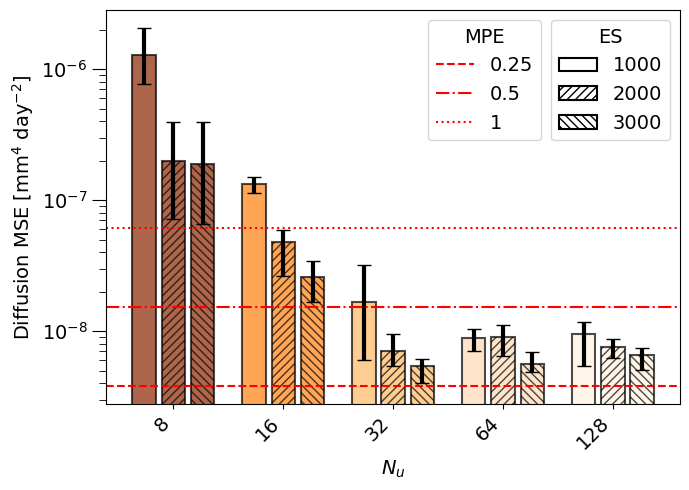

In [11]:
import numpy as np

def make_C_from_D(D, beta, n_points=1001):
    """
    Create a new function C(u) = k * D(u) such that the
    mean absolute percentage error is beta (%), and print
    MSE and absolute percentage error for u in [0, 1].

    Parameters
    ----------
    D : callable
        Original function D(u).
    beta : float
        Target absolute percentage error in percent.
    n_points : int
        Number of points in [0, 1] to use for error calculation.

    Returns
    -------
    C : callable
        New scaled function C(u) = k * D(u).
    """
    # Scale factor so that APE = beta (%)
    k = 1.0 + beta / 100.0  # could also use 1 - beta/100.0

    def C(u):
        return k * D(u)

    # Sample u in [0, 1]
    u = np.linspace(0.0, 1.0, n_points)
    D_vals = np.array([D(ui) for ui in u])
    C_vals = k * D_vals

    # Mean Squared Error over [0, 1]
    mse = np.mean((C_vals - D_vals) ** 2)

    # Mean Absolute Percentage Error (%)
    # avoid division by zero if D(u) = 0 somewhere
    mask = D_vals != 0
    if np.any(mask):
        ape = np.mean(
            np.abs((C_vals[mask] - D_vals[mask]) / D_vals[mask])
        ) * 100.0
    else:
        ape = np.nan  # undefined if D(u) is identically zero

    print(f"Scale factor k = {k}")
    print(f"MSE over [0, 1]: {mse}")
    print(f"Mean absolute percentage error over [0, 1]: {ape}")

    return C, mse, ape

# From file path info contstruct true D

def true_diffusion(u):
    return data_obj.theta_D * np.ones_like(u)


    #print("check PE:", np.mean(100*np.abs(alpha - D_true)/D_true))
mses = []
betas = [0.25, 0.5, 1]
for beta in betas:
    _,mse, ape =  make_C_from_D(true_diffusion, beta=beta)
    mses.append(mse)


name_full = os.path.join(name_intro, 'NNu4_to_128_D_loss_bars.png')



plot_settings = {
    'name': name_full,
    'fill': True,
    'line_width':2,
    'legend': {
        'panel': 2,
        'loc': (0.775,1),
        'loc_upd': (1, 1),
        'fontsize': 11,
        'ncols': 1
    },
    'xaxis': {
        'min': 0,
        'max': 3e4,
        'break': 1e3
    },
    'line_lengths': {
        'hlength': 7.5e3,
        'vlength_factor': 2
    },
    'line_widths_on_axis': {
        'hwidth': 2,
        'vwidth': 2
    },
    'fontsizes': {'xaxis':12, 'xtick_labels':11, 'yaxis':12, 'ytick_labels':11},
    "figsize": (7, 5),
}

plot_params = {
    key: [D_colors[i], linestyles[i], marker_styles[i], labels[i]]
    for i, key in enumerate(model_keys)
}

plot_diff_mse_lst(models_dics_list=binn_models_by_ES_chosen_D,
                  plot_params=plot_params,
                  label_list=[f"{ES}" for ES in binn_ES_list],
                  name=name_full,
                  figsize=(7, 5),
                  colors=D_colors,
                  bbox_to_anchor=(1, 1),
                  legend_size=14,
                  pe_bbox_to_anchor_offset=(-0.225, 0),
                  pe_label_list=[f"{i}" for i in betas],
                  pe_values=mses)